<a href="https://colab.research.google.com/github/Vaishnavi644/AI-Based-Hiring-Prediction-Project/blob/main/AI_Based_Hiring_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

###Load Dataset

In [ ]:
df = pd.read_csv("AI-Based Hiring Prediction System.csv")

df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


###Check Dataset Shape

In [ ]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 1000
Number of Columns : 11


###  Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


## Statistical Summary

In [ ]:
df.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


### Check Missing Values

In [ ]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


### Check Duplicate Rows

In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


### Check Data Types

In [ ]:
df.dtypes

,0
Resume_ID,int64
Name,object
Skills,object
Experience (Years),int64
Education,object
Certifications,object
Job Role,object
Recruiter Decision,object
Salary Expectation ($),int64
Projects Count,int64


### Display Column Names

In [ ]:
df.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

### Target Variable Distribution

In [ ]:
df["Recruiter Decision"].value_counts()

,count
Recruiter Decision,
Hire,812
Reject,188


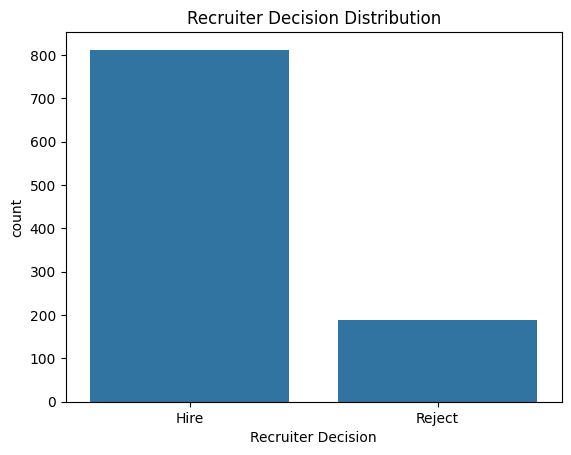

In [ ]:
sns.countplot(x="Recruiter Decision", data=df)

plt.title("Recruiter Decision Distribution")
plt.show()

## Separate Numerical & Categorical Columns

In [ ]:
categorical_columns = df.select_dtypes(include="object").columns

numerical_columns = df.select_dtypes(exclude="object").columns

print("Categorical Columns")
print(categorical_columns)

print()

print("Numerical Columns")
print(numerical_columns)

Categorical Columns
Index(['Name', 'Skills', 'Education', 'Certifications', 'Job Role',
       'Recruiter Decision'],
      dtype='object')

Numerical Columns
Index(['Resume_ID', 'Experience (Years)', 'Salary Expectation ($)',
       'Projects Count', 'AI Score (0-100)'],
      dtype='object')


### Explore Categorical Columns

In [ ]:
for col in categorical_columns:
    print("="*50)
    print(col)
    print(df[col].value_counts())
    print()

Name
Name
Sarah Jones        3
Crystal Parker     2
James Allen        2
Paul Wallace       2
John Wilson        2
                  ..
Jose Kirk          1
John Alvarez       1
Austin Saunders    1
Shannon Page       1
Abigail Brock      1
Name: count, Length: 989, dtype: int64

Skills
Skills
Python, Machine Learning                             11
SQL, Java                                            11
Ethical Hacking, Networking                          11
SQL, Python                                          10
SQL, Machine Learning                                10
                                                     ..
Ethical Hacking, Networking, Cybersecurity, Linux     1
C++, SQL, Java, React                                 1
Networking, Linux, Cybersecurity                      1
Linux, Cybersecurity, Networking, Ethical Hacking     1
NLP, Pytorch, TensorFlow, Python                      1
Name: count, Length: 238, dtype: int64

Education
Education
B.Sc      205
MBA       202
B

##Data Preprocessing

### Fill Missing Values

In [ ]:

df["Certifications"] = df["Certifications"].fillna("No Certification")

# Verify
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,0
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


### Drop Unnecessary Columns

In [ ]:
# Drop unnecessary columns

df.drop(["Resume_ID", "Name"], axis=1, inplace=True)

df.head()

,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,"TensorFlow, NLP, Pytorch",10,B.Sc,No Certification,AI Researcher,Hire,104895,8,100
1,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,"SQL, React, Java",4,PhD,No Certification,Software Engineer,Hire,87441,9,100


### Encode Categorical Variables

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    "Skills",
    "Education",
    "Certifications",
    "Job Role",
    "Recruiter Decision"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,226,10,0,3,0,0,104895,8,100
1,32,10,3,2,2,0,113002,1,100
2,46,1,3,1,1,0,71766,7,70
3,152,7,1,0,0,0,46848,0,95
4,221,4,4,3,3,0,87441,9,100


In [ ]:
print(df["Recruiter Decision"].value_counts())

Recruiter Decision
0    812
1    188
Name: count, dtype: int64


In [ ]:
print(le.classes_)

['Hire' 'Reject']


### Verify Encoding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Skills                  1000 non-null   int64
 1   Experience (Years)      1000 non-null   int64
 2   Education               1000 non-null   int64
 3   Certifications          1000 non-null   int64
 4   Job Role                1000 non-null   int64
 5   Recruiter Decision      1000 non-null   int64
 6   Salary Expectation ($)  1000 non-null   int64
 7   Projects Count          1000 non-null   int64
 8   AI Score (0-100)        1000 non-null   int64
dtypes: int64(9)
memory usage: 70.4 KB


In [ ]:
X.dtypes

,0
Skills,int64
Experience (Years),int64
Education,int64
Certifications,int64
Job Role,int64
Salary Expectation ($),int64
Projects Count,int64


#### The Skills column contains multiple comma-separated skills for each candidate. For simplicity, the entire skill combination was encoded using LabelEncoder as a single categorical value. In real-world machine learning applications, a multi-label encoding technique such as MultiLabelBinarizer or one-hot encoding would better represent individual skills and may improve model performance.

## Feature Selection

### Separate Features and Target

In [ ]:

X = df.drop(["Recruiter Decision", "AI Score (0-100)"], axis=1)
y = df["Recruiter Decision"]

print(X.shape)
print(y.shape)

(1000, 7)
(1000,)


## Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(800, 7)
(200, 7)


## Logistic Regression (Without Scaling)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

### Evaluate the Model

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.955
Precision: 0.8717948717948718
Recall   : 0.8947368421052632
F1 Score : 0.8831168831168831

Confusion Matrix
[[157   5]
 [  4  34]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       162
           1       0.87      0.89      0.88        38

    accuracy                           0.95       200
   macro avg       0.92      0.93      0.93       200
weighted avg       0.96      0.95      0.96       200



### Apply StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression (With Scaling)

In [ ]:
lr_scaled = LogisticRegression(max_iter=1000)

lr_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = lr_scaled.predict(X_test_scaled)

### Evaluate Scaled Logistic Regression

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_scaled))
print("Precision:", precision_score(y_test, y_pred_scaled))
print("Recall   :", recall_score(y_test, y_pred_scaled))
print("F1 Score :", f1_score(y_test, y_pred_scaled))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_scaled))

print("\nClassification Report")
print(classification_report(y_test, y_pred_scaled))

Accuracy : 0.955
Precision: 0.8717948717948718
Recall   : 0.8947368421052632
F1 Score : 0.8831168831168831

Confusion Matrix
[[157   5]
 [  4  34]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       162
           1       0.87      0.89      0.88        38

    accuracy                           0.95       200
   macro avg       0.92      0.93      0.93       200
weighted avg       0.96      0.95      0.96       200



### Compare Logistic Regression Before & After Scaling

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression (Without Scaling)",
              "Logistic Regression (With Scaling)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_scaled)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_scaled)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_scaled)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_scaled)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (Without Scaling),0.955,0.871795,0.894737,0.883117
1,Logistic Regression (With Scaling),0.955,0.871795,0.894737,0.883117


### Train KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

### Evaluate KNN

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report")
print(classification_report(y_test, y_pred_knn))

Accuracy : 0.915
Precision: 0.8181818181818182
Recall   : 0.7105263157894737
F1 Score : 0.7605633802816901

Confusion Matrix
[[156   6]
 [ 11  27]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       162
           1       0.82      0.71      0.76        38

    accuracy                           0.92       200
   macro avg       0.88      0.84      0.85       200
weighted avg       0.91      0.92      0.91       200



### Train Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

### Evaluate Decision Tree

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.965
Precision: 0.8974358974358975
Recall   : 0.9210526315789473
F1 Score : 0.9090909090909091

Confusion Matrix
[[158   4]
 [  3  35]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       162
           1       0.90      0.92      0.91        38

    accuracy                           0.96       200
   macro avg       0.94      0.95      0.94       200
weighted avg       0.97      0.96      0.97       200



### Compare All Models

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (Without Scaling)",
        "Logistic Regression (With Scaling)",
        "KNN",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_scaled),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_scaled),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_scaled),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_scaled),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (Without Scaling),0.955,0.871795,0.894737,0.883117
1,Logistic Regression (With Scaling),0.955,0.871795,0.894737,0.883117
2,KNN,0.915,0.818182,0.710526,0.760563
3,Decision Tree,0.965,0.897436,0.921053,0.909091


###Check Feature Importance


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Experience (Years),0.467615
6,Projects Count,0.397074
5,Salary Expectation ($),0.041221
0,Skills,0.036368
3,Certifications,0.027812
4,Job Role,0.018286
2,Education,0.011624


### Plot Feature Importance

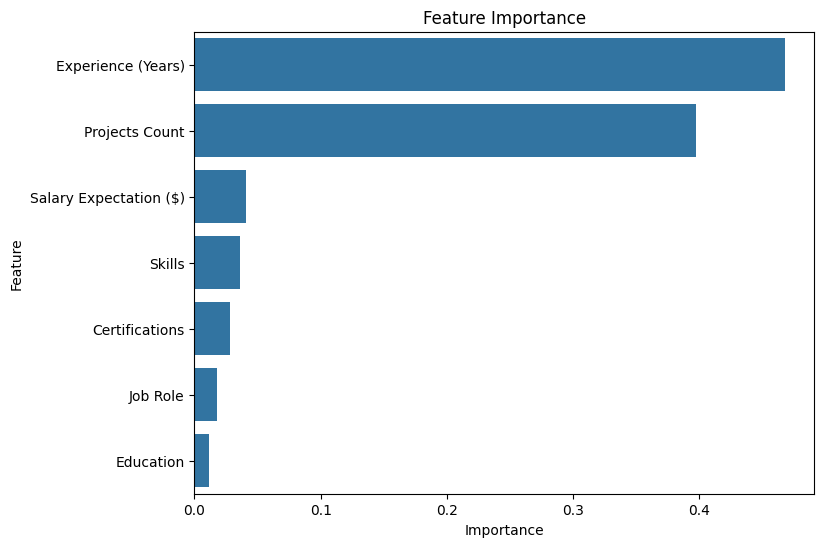

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

#### Decision Tree was selected as the best-performing model because it achieved the highest Accuracy, Precision, Recall, and F1 Score among all the evaluated models. Therefore, GridSearchCV was applied to optimize its hyperparameters using 5-fold cross-validation, aiming to improve the model's generalization performance.

## Hyperparameter Tuning (GridSearchCV)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1')

### Best Parameters

In [ ]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest F1 Score:")
print(grid.best_score_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best F1 Score:
0.8934449952797154


### Train Best Model

In [ ]:
best_dt = grid.best_estimator_

y_pred_best = best_dt.predict(X_test)

### Final Evaluation

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report")
print(classification_report(y_test, y_pred_best))

Accuracy : 0.945
Precision: 0.8648648648648649
Recall   : 0.8421052631578947
F1 Score : 0.8533333333333334

Confusion Matrix
[[157   5]
 [  6  32]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       162
           1       0.86      0.84      0.85        38

    accuracy                           0.94       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.94      0.94      0.94       200



##Conclusion

This project developed an AI-Based Hiring Prediction System using multiple Machine Learning algorithms. After preprocessing the dataset and encoding categorical variables, Logistic Regression, K-Nearest Neighbors, and Decision Tree classifiers were evaluated.

Decision Tree was selected as the best-performing model and further optimized using GridSearchCV, which improved the model's cross-validation F1-score to 0.893. However, on the held-out test set, the tuned Decision Tree (Accuracy: 0.945, F1: 0.853) performed slightly below the default Decision Tree (Accuracy: 0.965, F1: 0.909). This illustrates an important ML concept: hyperparameter tuning optimizes for generalization across cross-validation folds and does not always guarantee improvement on a single test split. Given this, the default Decision Tree may be considered the strongest model on this particular test set, while the tuned model remains valuable for its improved robustness across folds.

Removing the AI Score (0–100) feature prevented data leakage and resulted in a more realistic evaluation of the model. This demonstrates the importance of proper feature selection in building reliable Machine Learning models.

Overall, the project successfully predicts recruiter decisions based on candidate resume information and illustrates a complete end-to-end Machine Learning workflow.